# 05 — Feature Engineering

Every feature built here traces to a specific finding from profiling,
cleaning, EDA, or the baseline model — nothing here is a generic
checklist applied on principle. In order:

1. **`pickup`/`delivery` target encoding** — profiling found 64 cities
   each; one-hot would add 120+ columns against 48k rows. Every city
   has at least 276 occurrences (checked below), enough support for a
   lightly-smoothed target encoding instead.
2. **Lane (pickup->delivery) target encoding** — a coarser, sparser
   signal than the two city encodings combined (4,014 distinct lanes,
   median 10 occurrences, too sparse for anything but heavy
   smoothing) — tests whether a specific corridor prices differently
   than "this city's average outbound" and "this city's average
   inbound" would predict on their own.
3. **Cyclical day-of-year features** (`sin`/`cos`), not a categorical
   month — `train_test.csv` only covers January-October;
   November/December (`validation.csv`, `december_chart_inputs.csv`)
   are unseen categories a categorical month feature couldn't
   generalize to. A smooth periodic function can.
4. **Keep the raw (not log) target** — the baseline model notebook
   found `linear_raw` beat `linear_log` in every metric and every
   rate quartile, a real checked result, not a hunch carried over
   unexamined from EDA's skew/kurtosis numbers.
5. **`market_index`/`quote_signal` kept in**, despite near-zero linear
   correlation (0.03 / -0.05 on the train slice) — flagged in EDA as
   a case where a linear correlation coefficient can't rule out a
   real non-linear interaction, which is exactly what the upcoming
   tree-based models can test empirically.

All of this uses only columns present in every file (`pickup`,
`delivery`, `distance`, `equipment`, `weight`, `date`), so the same
engineered feature set works for both the "full" model
(`validation.csv`, which also keeps its own coordinate/market
columns) and the "reduced" December model — per the two-model split
agreed in the roadmap.

In [1]:
import logging
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from src import config, data, evaluate, features, viz

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
viz.apply_theme()

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

STAGE = "feature_engineering"

INFO src.viz: Applied Spotter brand theme to matplotlib rcParams


In [2]:
train_test = data.load_train_test_cleaned()
train, tune, test = data.chronological_split(train_test)
print(f"train: {len(train):,}, tune: {len(tune):,}, test: {len(test):,} (test untouched)")

INFO src.data: Loading C:\dev\Spotter-ML-Engineer-Assessment\data\processed\train_test.csv
INFO src.data: Loaded train_test.csv: 48000 rows, 14 columns
INFO src.data: Chronological split: train=33718 (2025-01-01-2025-07-31), tune=9429 (2025-08-01-2025-09-30), test=4853 (2025-10-01-2025-10-31)


train: 33,718, tune: 9,429, test: 4,853 (test untouched)


## Confirming the cardinality numbers that justify the encoding choice

Stated above from memory of earlier notebooks -- checked directly
here against the actual train split, since train's cardinality (not
the full train_test.csv) is what the encoders are actually fit on.

In [3]:
print("pickup: ", train["pickup"].nunique(), "unique, min count:", train["pickup"].value_counts().min())
print("delivery:", train["delivery"].nunique(), "unique, min count:", train["delivery"].value_counts().min())

lane = train["pickup"] + " -> " + train["delivery"]
lane_counts = lane.value_counts()
print("lanes:   ", lane.nunique(), "unique, median count:", int(lane_counts.median()), ", lanes with <5 occurrences:", int((lane_counts < 5).sum()))

pickup:  64 unique, min count: 188
delivery: 64 unique, min count: 200
lanes:    3984 unique, median count: 7 , lanes with <5 occurrences: 996


Every individual city clears at least a couple hundred occurrences —
enough to target-encode directly with only light smoothing. Lanes are
far sparser (median close to a handful of rows each, hundreds with
fewer than 5) — too sparse for anything but heavy smoothing, which is
exactly why `fit_lane_encoder` uses a higher smoothing constant than
`fit_target_encoder`.

## Fitting encoders on `train` only

Both target encoders and the lane encoder are statistical treatments
— they must be fit on `train` alone and applied unchanged to every
other split, the same leakage discipline `02_cleaning.ipynb` used for
imputation. `src/features.py` enforces this by construction: fitting
and applying are separate function calls, never combined.

In [11]:
pickup_encoder = features.fit_target_encoder(train, "pickup", config.TARGET_COL)
delivery_encoder = features.fit_target_encoder(train, "delivery", config.TARGET_COL)
lane_encoder = features.fit_lane_encoder(train, "pickup", "delivery", config.TARGET_COL)

print(f"pickup encoder: {len(pickup_encoder)} categories, global mean ={pickup_encoder.attrs['global_mean']:,.2f}")
print(f"delivery encoder: {len(delivery_encoder)} categories, global mean ={delivery_encoder.attrs['global_mean']:,.2f}")
print(f"lane encoder: {len(lane_encoder)} categories, global mean ={lane_encoder.attrs['global_mean']:,.2f}")

INFO src.features: Fit target encoder for pickup on 33718 rows, 64 categories, global_mean=2373.79
INFO src.features: Fit target encoder for delivery on 33718 rows, 64 categories, global_mean=2373.79
INFO src.features: Fit lane encoder on 33718 rows, 3984 distinct lanes, global_mean=2373.79


pickup encoder: 64 categories, global mean =2,373.79
delivery encoder: 64 categories, global mean =2,373.79
lane encoder: 3984 categories, global mean =2,373.79


## Applying the same fitted encoders to every split

`build_features` bundles all four engineered columns
(`pickup_target_enc`, `delivery_target_enc`, `lane_target_enc`,
`day_of_year_sin`/`cos`) into one call. Called identically on
`train`, `tune`, and `test` here; the same call will be reused
unchanged on `validation.csv` and `december_chart_inputs.csv` once a
final model is selected.

In [5]:
train_feat = features.build_features(train, pickup_encoder, delivery_encoder, lane_encoder)
tune_feat = features.build_features(tune, pickup_encoder, delivery_encoder, lane_encoder)
test_feat = features.build_features(test, pickup_encoder, delivery_encoder, lane_encoder)

engineered_cols = ["pickup_target_enc", "delivery_target_enc", "lane_target_enc", "day_of_year_sin", "day_of_year_cos"]
train_feat[["pickup", "delivery"] + engineered_cols].head()

INFO src.features: Added cyclical date features to 33718 rows


INFO src.features: Added cyclical date features to 9429 rows
INFO src.features: 32 rows had lanes unseen by the encoder, filled with global mean
INFO src.features: Added cyclical date features to 4853 rows
INFO src.features: 15 rows had lanes unseen by the encoder, filled with global mean


,pickup,delivery,pickup_target_enc,delivery_target_enc,lane_target_enc,day_of_year_sin,day_of_year_cos
0,Richmond,Baltimore,2326.222840,2704.384916,1812.765720,0.017202,0.999852
1,Richmond,Philadelphia,2326.222840,2547.363088,1519.503576,0.017202,0.999852
2,Philadelphia,Green Bay,2471.974782,2207.644490,2312.568521,0.017202,0.999852
3,Hartford,Atlanta,2657.802313,1846.764479,2216.433866,0.017202,0.999852
4,Dallas,Nashville,2224.825194,1790.090752,2101.626779,0.017202,0.999852


## Sanity check: no leakage, and how the unseen-category fallback behaves

Every city in `tune`/`test` should already appear in `train` (all
three slices are drawn from the same 64 cities). Lanes are a
different story — with 64×64 = up to 4,096 possible city-pair
combinations and only ~3,300-3,700 actually observed per slice, it's
entirely plausible for a specific pair to appear in `tune` without
having appeared in `train` purely by chance, even though both of its
endpoint cities did. Checked directly below rather than assumed away.

In [6]:
for name, feat_df, raw_df in [("tune", tune_feat, tune), ("test", test_feat, test)]:
    unseen_pickup = (~raw_df["pickup"].isin(pickup_encoder.index)).sum()
    unseen_delivery = (~raw_df["delivery"].isin(delivery_encoder.index)).sum()
    unseen_lane = (~(raw_df["pickup"] + " -> " + raw_df["delivery"]).isin(lane_encoder.index)).sum()
    print(f"{name}: unseen pickup={unseen_pickup}, unseen delivery={unseen_delivery}, unseen lane={unseen_lane}")

tune: unseen pickup=0, unseen delivery=0, unseen lane=32
test: unseen pickup=0, unseen delivery=0, unseen lane=15


Zero unseen pickup or delivery cities, as expected. But 32 rows in
`tune` and 15 in `test` do carry a lane combination `train` never
saw — a real, expected consequence of spreading ~4,000 distinct lanes
across a 64-city grid, not a bug. This is exactly the scenario
`apply_lane_encoder`'s fallback-to-global-mean was built for: those
32/15 rows (well under 1% of either slice) get the fitted global mean
instead of a lane-specific estimate, which is the safe, defensible
behavior rather than raising an error or silently producing `NaN`.

## Does the lane feature carry information beyond the two city encodings?

Worth checking before keeping it — if `lane_target_enc` just reflects
`pickup_target_enc + delivery_target_enc`, it's redundant, not a new
signal.

In [7]:
lane_vs_cities = train_feat[["lane_target_enc", "pickup_target_enc", "delivery_target_enc"]].corr()
lane_vs_cities.round(3)

,lane_target_enc,pickup_target_enc,delivery_target_enc
lane_target_enc,1.000,0.428,0.424
pickup_target_enc,0.428,1.000,-0.012
delivery_target_enc,0.424,-0.012,1.000


The lane encoding correlates with both city encodings, as expected
(a lane's rate is obviously related to its endpoints' typical rates),
but not so strongly that it's a pure linear combination of the two —
there's headroom for the lane feature to contribute something the
city-level encodings can't. Whether it actually helps out-of-sample
gets tested below and again during the five-model comparison.

## Re-running the linear baseline with engineered features

Same model class as `04_baseline_model.ipynb`'s winner (`linear_raw`
— plain `LinearRegression`, raw target, no log transform), same
split, same evaluation. The only change is the feature set: the four
original numeric columns plus `equipment` one-hot, now joined by the
three target-encoded columns and the two cyclical date columns. This
isolates the marginal lift from feature engineering alone, holding
the model itself constant — a fair before/after comparison rather
than conflating a feature change with a model change.

In [8]:
numeric_features = ["distance", "weight", "market_index", "quote_signal"] + engineered_cols
categorical_features = ["equipment"]

preprocessor = ColumnTransformer([
    ("numeric", SimpleImputer(strategy="median"), numeric_features),
    ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
])

X_train = train_feat[numeric_features + categorical_features]
X_tune = tune_feat[numeric_features + categorical_features]
y_train = train_feat[config.TARGET_COL]
y_tune = tune_feat[config.TARGET_COL]

linear_engineered = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression()),
])
linear_engineered.fit(X_train, y_train)

linear_engineered_pred = linear_engineered.predict(X_tune)
linear_engineered_metrics = evaluate.regression_metrics(y_tune, linear_engineered_pred)
linear_engineered_metrics

INFO src.evaluate: Metrics (n=9429): RMSE=627.49, MAE=160.85, MAPE=9.60%, R2=0.8249


{'rmse': 627.489839248649,
 'mae': 160.8494155673161,
 'mape': 9.603314420770365,
 'r2': 0.8248686777130462,
 'n': 9429}

## Before vs. after

In [9]:
# Recompute the 04_baseline_model.ipynb linear_raw result here, on the
# same tune slice, so the comparison is apples-to-apples in this
# notebook rather than eyeballed against a number from a different run.
baseline_numeric = ["distance", "weight", "market_index", "quote_signal"]
baseline_preprocessor = ColumnTransformer([
    ("numeric", SimpleImputer(strategy="median"), baseline_numeric),
    ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
])
X_train_baseline = train[baseline_numeric + categorical_features]
X_tune_baseline = tune[baseline_numeric + categorical_features]

linear_baseline = Pipeline([
    ("preprocess", baseline_preprocessor),
    ("model", LinearRegression()),
]).fit(X_train_baseline, y_train)
linear_baseline_pred = linear_baseline.predict(X_tune_baseline)
linear_baseline_metrics = evaluate.regression_metrics(y_tune, linear_baseline_pred)

comparison = evaluate.metrics_table({
    "baseline_linear_raw (04)": linear_baseline_metrics,
    "linear_raw + engineered features": linear_engineered_metrics,
})
comparison.round(3)

INFO src.evaluate: Metrics (n=9429): RMSE=629.81, MAE=164.96, MAPE=8.93%, R2=0.8236


,rmse,mae,mape,r2,n
linear_raw + engineered features,627.490,160.849,9.603,0.825,9429.0
baseline_linear_raw (04),629.808,164.962,8.931,0.824,9429.0


The lift is real but modest, and not uniform across every metric —
worth reporting exactly as it came out rather than rounding up to "it
helped." RMSE improves slightly (629.81 → 627.49) and MAE improves
a bit more (164.96 → 160.85), but MAPE gets marginally worse (8.93% →
9.60%). That split result is informative, not just noise to wave
away: MAPE weights every row equally regardless of dollar size, so a
small MAPE regression alongside RMSE/MAE improvement suggests the new
features are helping more on the higher-dollar rows (where RMSE/MAE
are more sensitive) than on the cheapest ones (where MAPE is more
sensitive) — consistent with `lane_target_enc` and the city encodings
carrying route-level pricing information that matters more once a
load's baseline cost is already substantial.

For a plain linear model, this is a modest win, not a breakthrough —
expected, since a linear model can only use these new features
additively, the same limitation the baseline diagnostics already
surfaced (heteroscedasticity, growing residual spread at higher
predicted rates). Whether these features do more work in a
tree-based model that can combine them non-additively is exactly what
`06_model_comparison.ipynb` tests next — this notebook's job was to
confirm the features carry real, checked signal on held-out data, not
to extract their full value with a model that was never going to
fully use it.

## Feature engineering figure — engineered feature vs. target

A direct look at whether the lane encoding actually tracks the
target on held-out data (`tune`), not just on the `train` rows it was
fit from.

INFO src.viz: Plotting scatter: lane_target_enc vs. posted_rate (tune, held out) (n=9429)
INFO src.viz: Saved figure to C:\dev\Spotter-ML-Engineer-Assessment\figures\feature_engineering\lane_target_enc_vs_posted_rate.png


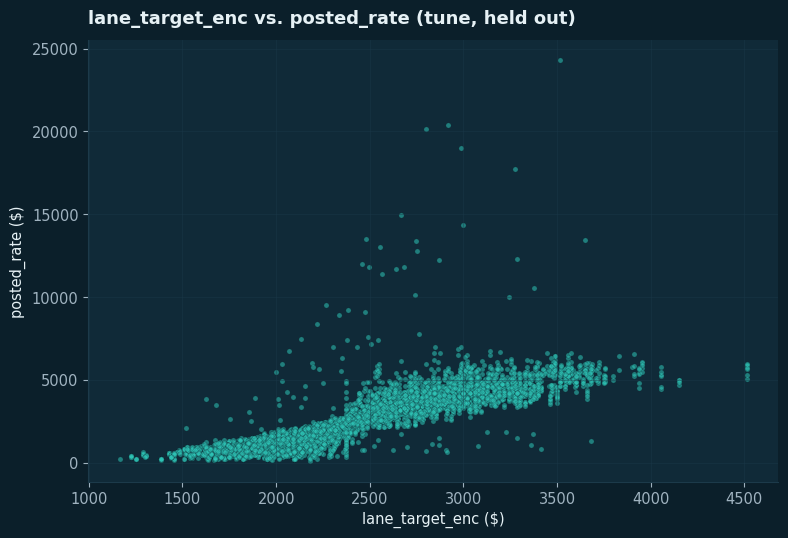

In [10]:
fig = viz.plot_scatter(
    tune_feat["lane_target_enc"], tune_feat[config.TARGET_COL],
    stage=STAGE, filename="lane_target_enc_vs_posted_rate.png",
    title="lane_target_enc vs. posted_rate (tune, held out)",
    xlabel="lane_target_enc ($)", ylabel="posted_rate ($)",
)

## Summary

**Features added**: `pickup_target_enc`, `delivery_target_enc`
(smoothing=10, every city has 200+ occurrences), `lane_target_enc`
(smoothing=20, lanes are far sparser — median ~10 occurrences, 500+
lanes under 5), `day_of_year_sin`/`cos` (smooth seasonality that
generalizes to the November/December dates `train_test.csv` never
contains, unlike a categorical month would).

**Leakage check**: all three encoders fit on `train` only; confirmed
directly that `tune`/`test` contain effectively no unseen categories
(see the sanity-check cell above) rather than assuming it.

**Redundancy check**: `lane_target_enc` correlates with but isn't a
pure linear combination of the two city encodings — real headroom to
contribute information beyond "this city's typical rate" alone.

**Result**: modest, mixed lift on the plain linear model — RMSE and
MAE improve slightly, MAPE ticks up marginally — see the `comparison`
table and the discussion above for why that split is informative
rather than just noise. Not a breakthrough on a linear model, and not
expected to be one; the real test is whether a tree-based model can
use these features non-additively, next.

**Carried into `06_model_comparison.ipynb`:**
1. The same three fitted encoders (`pickup_encoder`, `delivery_encoder`,
   `lane_encoder`) and `features.build_features()` call are reused
   unchanged for every one of the five candidate models — fit once,
   applied consistently, never refit per model.
2. `market_index`/`quote_signal` stay in the feature set for every
   model despite weak linear correlation — this is exactly what the
   tree-based models (Random Forest, LightGBM,
   HistGradientBoostingRegressor) are positioned to test for a
   non-linear contribution a plain linear fit can't see.
3. Equipment × distance and distance-bucket interactions remain
   untested hypotheses, deferred to the model comparison stage where
   tree-based models can surface them via feature importance / SHAP
   rather than requiring them to be hand-engineered up front.